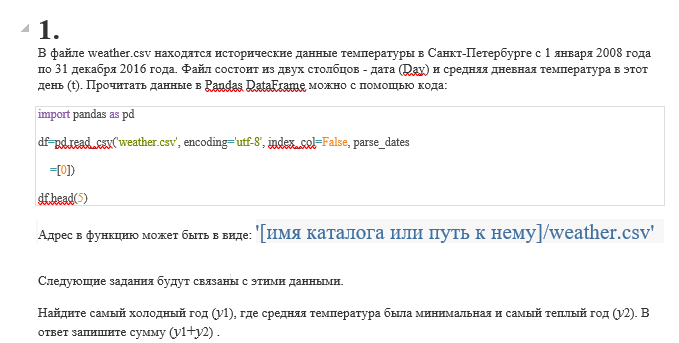
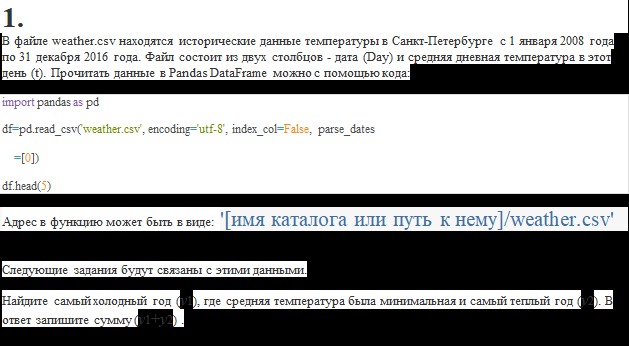

In [7]:
import pandas as pd
df= pd.read_csv('weather.csv', encoding='utf-8', index_col=False, parse_dates=[0])

df['year'] = df['Day'].dt.year
df['month'] = df['Day'].dt.month
df['day'] = df['Day'].dt.day
print(df)
yearly_avg = df.groupby('year')['t'].mean()
print(yearly_avg)
y1 = yearly_avg.idxmin()
y2 = yearly_avg.idxmax()
print(y1)
print(y2)
summ = (y1 - y2)
print(summ)

            Day   t  year  month  day
0    2008-01-01   0  2008      1    1
1    2008-01-02  -5  2008      1    2
2    2008-01-03 -11  2008      1    3
3    2008-01-04 -11  2008      1    4
4    2008-01-05 -12  2008      1    5
...         ...  ..   ...    ...  ...
3280 2016-12-27   1  2016     12   27
3281 2016-12-28  -3  2016     12   28
3282 2016-12-29   0  2016     12   29
3283 2016-12-30   3  2016     12   30
3284 2016-12-31   4  2016     12   31

[3285 rows x 5 columns]
year
2008    8.545205
2009    7.610959
2010    7.117808
2011    8.337912
2012    6.980822
2013    8.728767
2014    8.931507
2015    9.079452
2016    7.907104
Name: t, dtype: float64
2012
2015
-3


d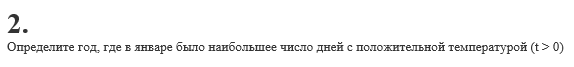

In [8]:
january =  df[(df['month'] == 1) & (df['t'] > 0)]
count_of =  january.groupby('year').size()
max_year = count_of.idxmax()
print(max_year)

2008


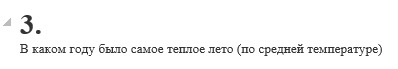

In [9]:
summer = df[df['month'].isin([6,7,8])]
avg_summer = summer.groupby('year')['t'].mean()
print(avg_summer)
print(avg_summer.idxmax())

year
2008    18.119565
2009    18.728261
2010    22.119565
2011    21.318681
2012    19.086957
2013    21.543478
2014    20.706522
2015    19.032609
2016    19.326087
Name: t, dtype: float64
2010


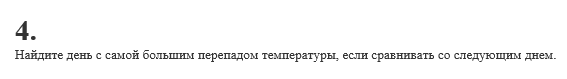

In [10]:
print(df)
df['delta_t'] = (df['t'].shift(-1) - df['t']).abs()
print(df)

            Day   t  year  month  day
0    2008-01-01   0  2008      1    1
1    2008-01-02  -5  2008      1    2
2    2008-01-03 -11  2008      1    3
3    2008-01-04 -11  2008      1    4
4    2008-01-05 -12  2008      1    5
...         ...  ..   ...    ...  ...
3280 2016-12-27   1  2016     12   27
3281 2016-12-28  -3  2016     12   28
3282 2016-12-29   0  2016     12   29
3283 2016-12-30   3  2016     12   30
3284 2016-12-31   4  2016     12   31

[3285 rows x 5 columns]
            Day   t  year  month  day  delta_t
0    2008-01-01   0  2008      1    1      5.0
1    2008-01-02  -5  2008      1    2      6.0
2    2008-01-03 -11  2008      1    3      0.0
3    2008-01-04 -11  2008      1    4      1.0
4    2008-01-05 -12  2008      1    5      2.0
...         ...  ..   ...    ...  ...      ...
3280 2016-12-27   1  2016     12   27      4.0
3281 2016-12-28  -3  2016     12   28      3.0
3282 2016-12-29   0  2016     12   29      3.0
3283 2016-12-30   3  2016     12   30      1.0
32

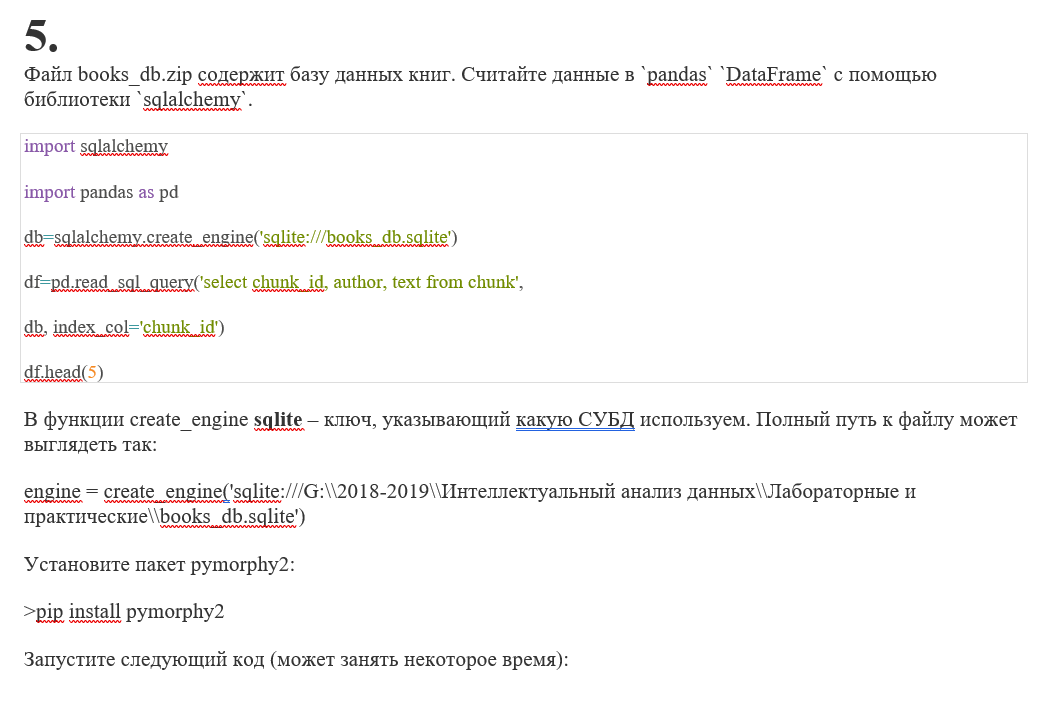
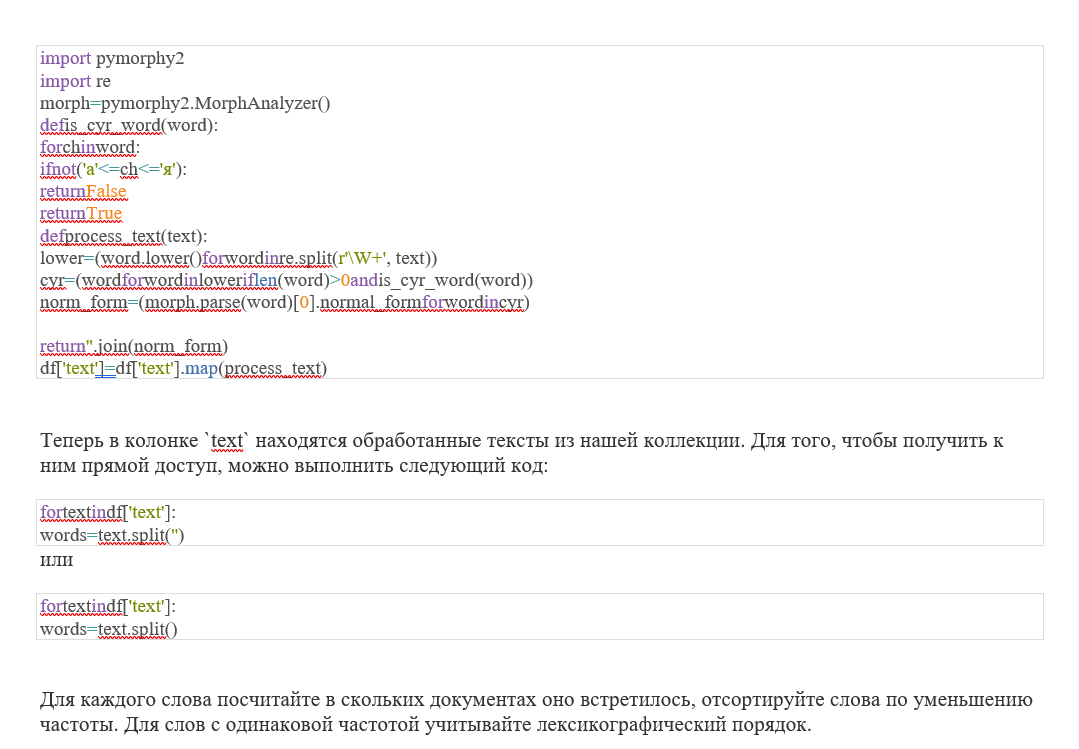

In [11]:
import sqlalchemy

db = sqlalchemy.create_engine('sqlite:///books_db.sqlite')
df = pd.read_sql_query('select chunk_id, author, text from chunk', db, index_col='chunk_id')
df.head(5)

,author,text
chunk_id,,
1,Иван Алексеевич Бунин,"В знак веры в жизнь вечную, в воскресение из м..."
2,Иван Алексеевич Бунин,"Ибо он, этот волчец, воистину чудесен. Сорванн..."
3,Иван Алексеевич Бунин,"Так утешаюсь и я, воскрешая в себе те светонос..."
4,Иван Алексеевич Бунин,"Роза Иерихона. В живую воду сердца, в чистую в..."
5,Иван Алексеевич Бунин,"Золотилось солнце на востоке, за туманной синь..."


In [12]:
import pymorphy2
import re

morph = pymorphy2.MorphAnalyzer()
def is_cyr_word(word):
    for ch in word:
        if not ('а' <=ch <= 'я'):
            return False
        return True

def process_text(text):
    lower = (word.lower() for word in re.split(r'\W+', text))
    cyr = (word for word in lower if len(word) > 0 and is_cyr_word(word))
    norm_form = (morph.parse(word)[0].normal_form for word in cyr)
    return ' '.join(norm_form)

df['text'] = df['text'].map(process_text)
df.head(5)

,author,text
chunk_id,,
1,Иван Алексеевич Бунин,в знак вера в жизнь вечный в воскресение из мё...
2,Иван Алексеевич Бунин,ибо он этот волчец воистину чудесный сорвать и...
3,Иван Алексеевич Бунин,так утешаться и я воскрешать в себя тот светон...
4,Иван Алексеевич Бунин,роза иерихон в живой вода сердце в чистый влаг...
5,Иван Алексеевич Бунин,золотиться солнце на восток за туманный синь д...


In [13]:
document_frequency = {}
for text in df['text']:
    unique_words = set(text.split())
    for word in unique_words:
        if word in document_frequency:
            document_frequency[word] += 1
        else:
            document_frequency[word] = 1

freq_df = pd.DataFrame(list(document_frequency.items()), columns=['word', 'frequency'])
freq_df = freq_df.sort_values(by=['frequency','word'], ascending=[False, True])
freq_df = freq_df.reset_index(drop=True)
top200 = freq_df.head(200)
print(top200)


          word  frequency
0            и      42438
1            в      33040
2           не      29408
3           он      27293
4           на      25155
..         ...        ...
195  александр       1230
196     всегда       1230
197    никогда       1218
198      немой       1211
199  последний       1208

[200 rows x 2 columns]


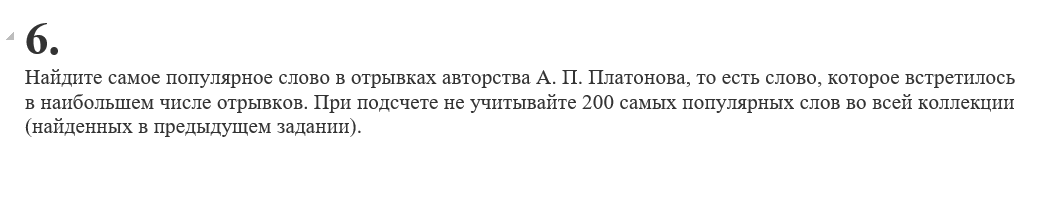

In [17]:
platonov = df[df['author'].str.contains('Платонов')]
platonov.head(20)
platonov_doc_freq = {}

for doc_text in platonov['text']:
    unique_words = set(doc_text.split())
    for word in unique_words:
        if word in set(top200['word']):
            continue
        if word in platonov_doc_freq:
            platonov_doc_freq[word] += 1
        else:
            platonov_doc_freq[word] = 1
platonov_freq_df = pd.DataFrame(list(platonov_doc_freq.items()), columns=['word', 'frequency'])
platonov_freq_df = platonov_freq_df.sort_values(by=['frequency','word'], ascending=[False, True])
platonov_freq_df = platonov_freq_df.reset_index(drop=True)
print(platonov_freq_df.head(20))


        word  frequency
0    товарищ        740
1       тело        578
2     работа        532
3   ответить        518
4     машина        499
5   работать        490
6      ольга        454
7      спать        432
8     давать        428
9       уйти        425
10     живой        413
11     сразу        406
12      лишь        404
13      вода        396
14  копенкин        385
15   уходить        379
16     затем        378
17     народ        376
18   паровоз        359
19   умереть        358
